# 05 — Evaluasi dan Perbandingan Model

Notebook ini bertugas untuk memuat ketiga model yang telah dilatih (MobileNetV2, ResNet50, dan EfficientNetB0), mengevaluasinya secara mendalam menggunakan test set, dan membandingkan performanya berdasarkan berbagai metrik (Accuracy, Precision, Recall, F1-Score, Inference Time, serta Model Size).

In [ ]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score
)

BASE_DIR = Path.cwd().parent  # backend/
sys.path.insert(0, str(BASE_DIR))

from app.services.preprocessing import get_data_loaders, get_class_names
from app.models.cnn_models import create_mobilenetv2, create_resnet50, create_efficientnetb0
from app.utils.config import MODEL_MOBILENET_DIR, MODEL_RESNET_DIR, MODEL_EFFICIENTNET_DIR, REPORTS_EVAL_DIR, DEVICE

print(f"🖥️  Device: {DEVICE}")

🖥️  Device: cpu


### Load Data & Model

In [17]:
class_names = get_class_names()
num_classes = len(class_names)
_, test_loader = get_data_loaders()

# Load MobileNetV2 (95 kelas)
mobilenet = create_mobilenetv2(num_classes=num_classes, pretrained=False)
mobilenet.load_state_dict(torch.load(os.path.join(MODEL_MOBILENET_DIR, "mobilenetv2_best.pth"), map_location=DEVICE))
mobilenet = mobilenet.to(DEVICE)
mobilenet.eval()

# Load ResNet50 (checkpoint lama = 98 kelas)
RESNET_NUM_CLASSES = 98
resnet = create_resnet50(num_classes=RESNET_NUM_CLASSES, pretrained=False)
resnet.load_state_dict(torch.load(os.path.join(MODEL_RESNET_DIR, "resnet50_best.pth"), map_location=DEVICE))
resnet = resnet.to(DEVICE)
resnet.eval()

# Load EfficientNetB0 (95 kelas)
efficientnet = create_efficientnetb0(num_classes=num_classes, pretrained=False)
efficientnet.load_state_dict(torch.load(os.path.join(MODEL_EFFICIENTNET_DIR, "efficientnetb0_best.pth"), map_location=DEVICE))
efficientnet = efficientnet.to(DEVICE)
efficientnet.eval()

print(f"Ketiga model berhasil dimuat")
print(f"Jumlah kelas dataset: {num_classes}")
print(f"ResNet50 checkpoint: {RESNET_NUM_CLASSES} kelas")
print(f"Test batches: {len(test_loader)}")

✅ Combined dataset sudah ada: 95 kelas
✅ Combined dataset sudah ada: 95 kelas

📊 Dataset Info:
   Total gambar: 12031
   Total kelas:  95
   Train: 9624 gambar (80%)
   Test:  2407 gambar (20%)
   Train batches: 301
   Test batches:  76
Ketiga model berhasil dimuat
Jumlah kelas dataset: 95
ResNet50 checkpoint: 98 kelas
Test batches: 76


### Fungsi Evaluasi

In [19]:
def evaluate_model(model, test_loader, device, model_name="Model"):
    """Evaluasi model pada test set, return prediksi dan metrik."""
    all_preds = []
    all_labels = []
    inference_times = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            start = time.time()
            outputs = model(inputs)
            inference_times.append(time.time() - start)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Metrik
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    avg_inference = np.mean(inference_times) * 1000  # ms
    
    print(f"\n{'='*50}")
    print(f"📊 {model_name} — Test Evaluation")
    print(f"{'='*50}")
    print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   Avg Inference: {avg_inference:.2f} ms/batch")
    
    return {
        'preds': all_preds,
        'labels': all_labels,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'avg_inference_ms': avg_inference
    }

results_mobilenet = evaluate_model(mobilenet, test_loader, DEVICE, "MobileNetV2")
results_resnet = evaluate_model(resnet, test_loader, DEVICE, "ResNet50")
results_efficientnet = evaluate_model(efficientnet, test_loader, DEVICE, "EfficientNetB0")


📊 MobileNetV2 — Test Evaluation
   Accuracy:  0.9730 (97.30%)
   Precision: 0.9739
   Recall:    0.9730
   F1-Score:  0.9729
   Avg Inference: 378.82 ms/batch

📊 ResNet50 — Test Evaluation
   Accuracy:  0.6984 (69.84%)
   Precision: 0.7309
   Recall:    0.6984
   F1-Score:  0.7039
   Avg Inference: 1581.56 ms/batch

📊 EfficientNetB0 — Test Evaluation
   Accuracy:  0.9884 (98.84%)
   Precision: 0.9891
   Recall:    0.9884
   F1-Score:  0.9884
   Avg Inference: 307.96 ms/batch


### Confusion Matrix

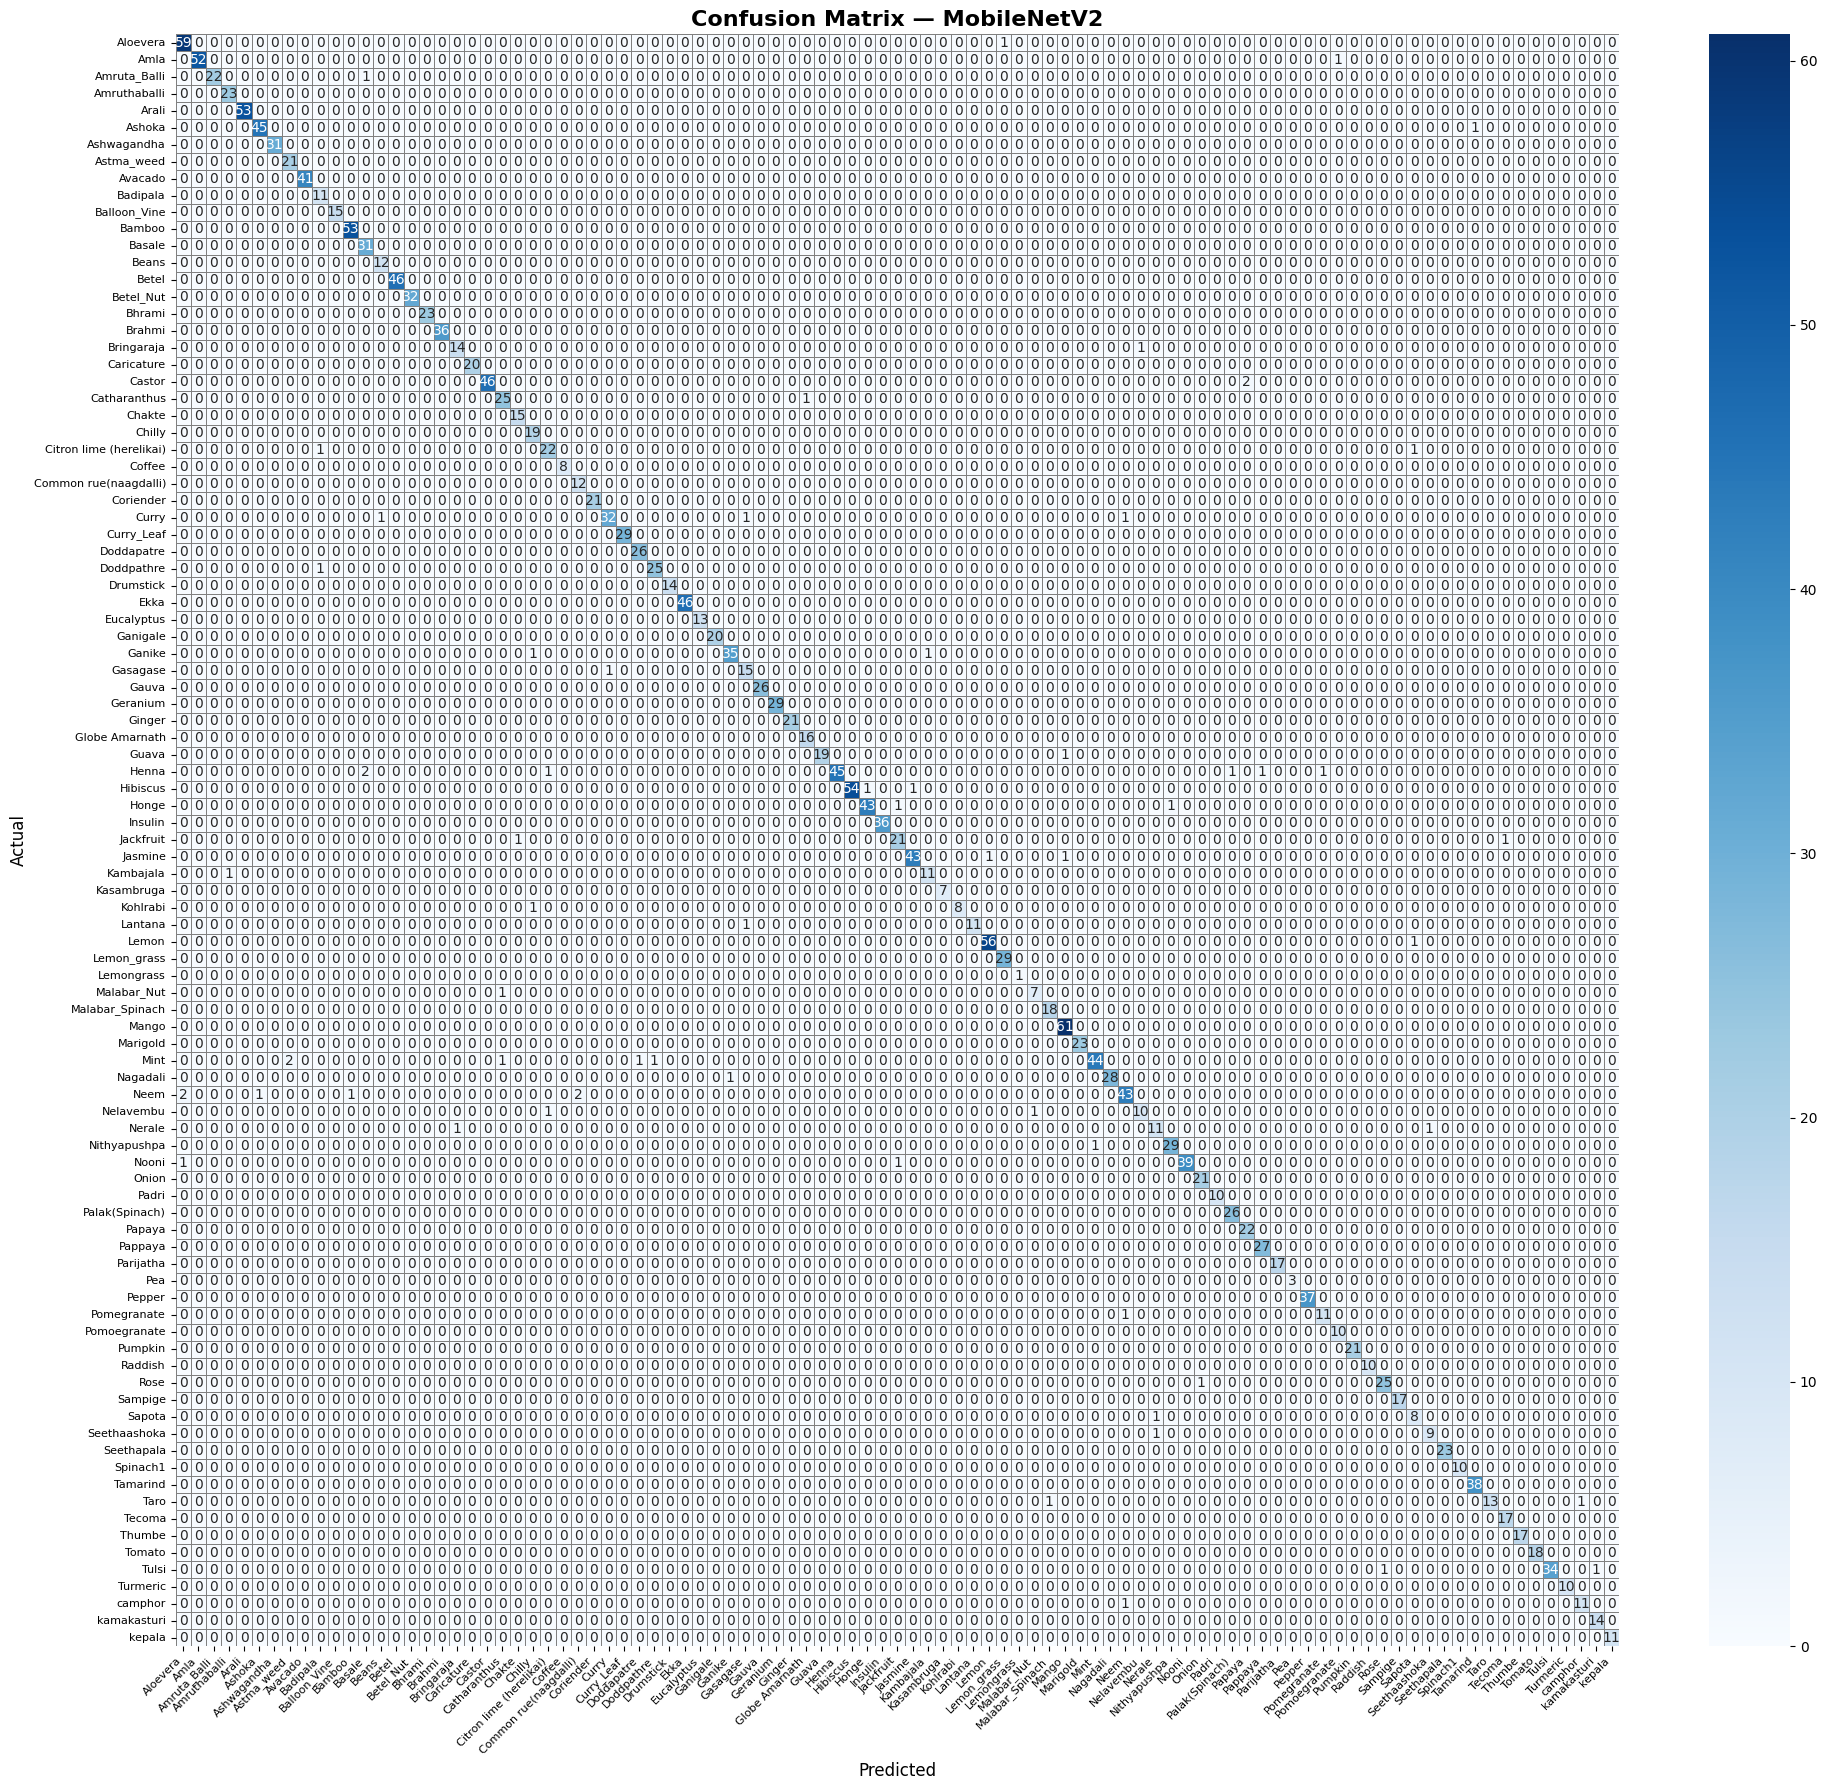

💾 Confusion matrix disimpan: D:\SMT 6\ML\BE\backend-apm-herbify\reports\evaluation\confusion_matrix_mobilenetv2.png


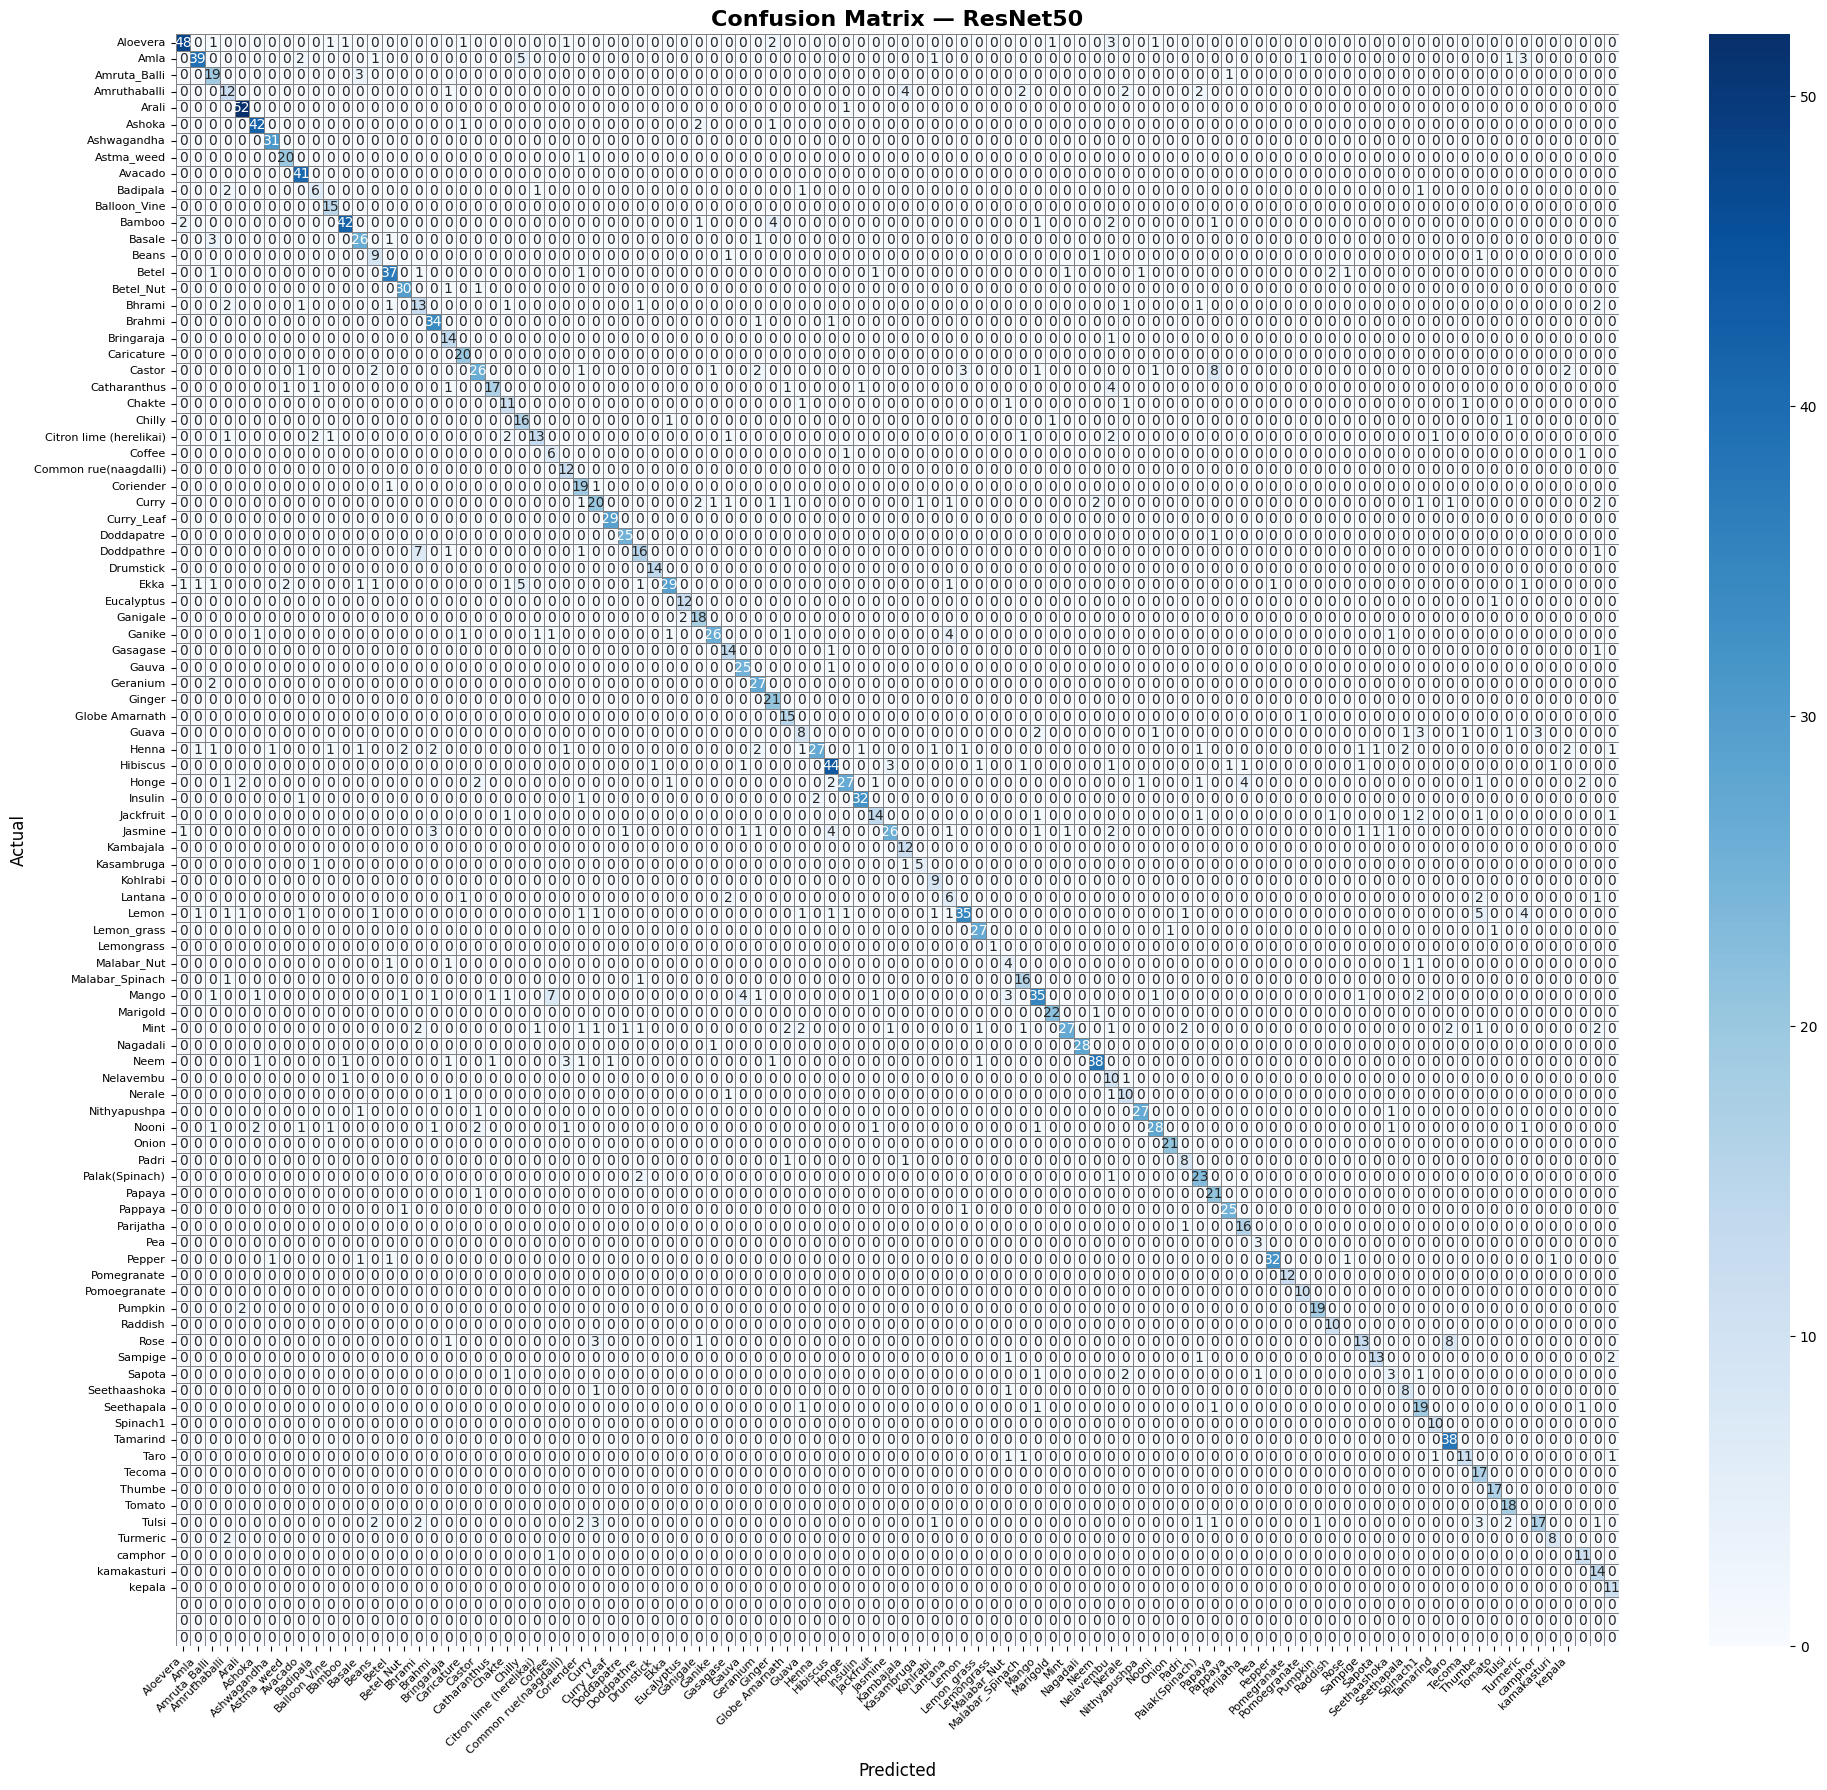

💾 Confusion matrix disimpan: D:\SMT 6\ML\BE\backend-apm-herbify\reports\evaluation\confusion_matrix_resnet50.png


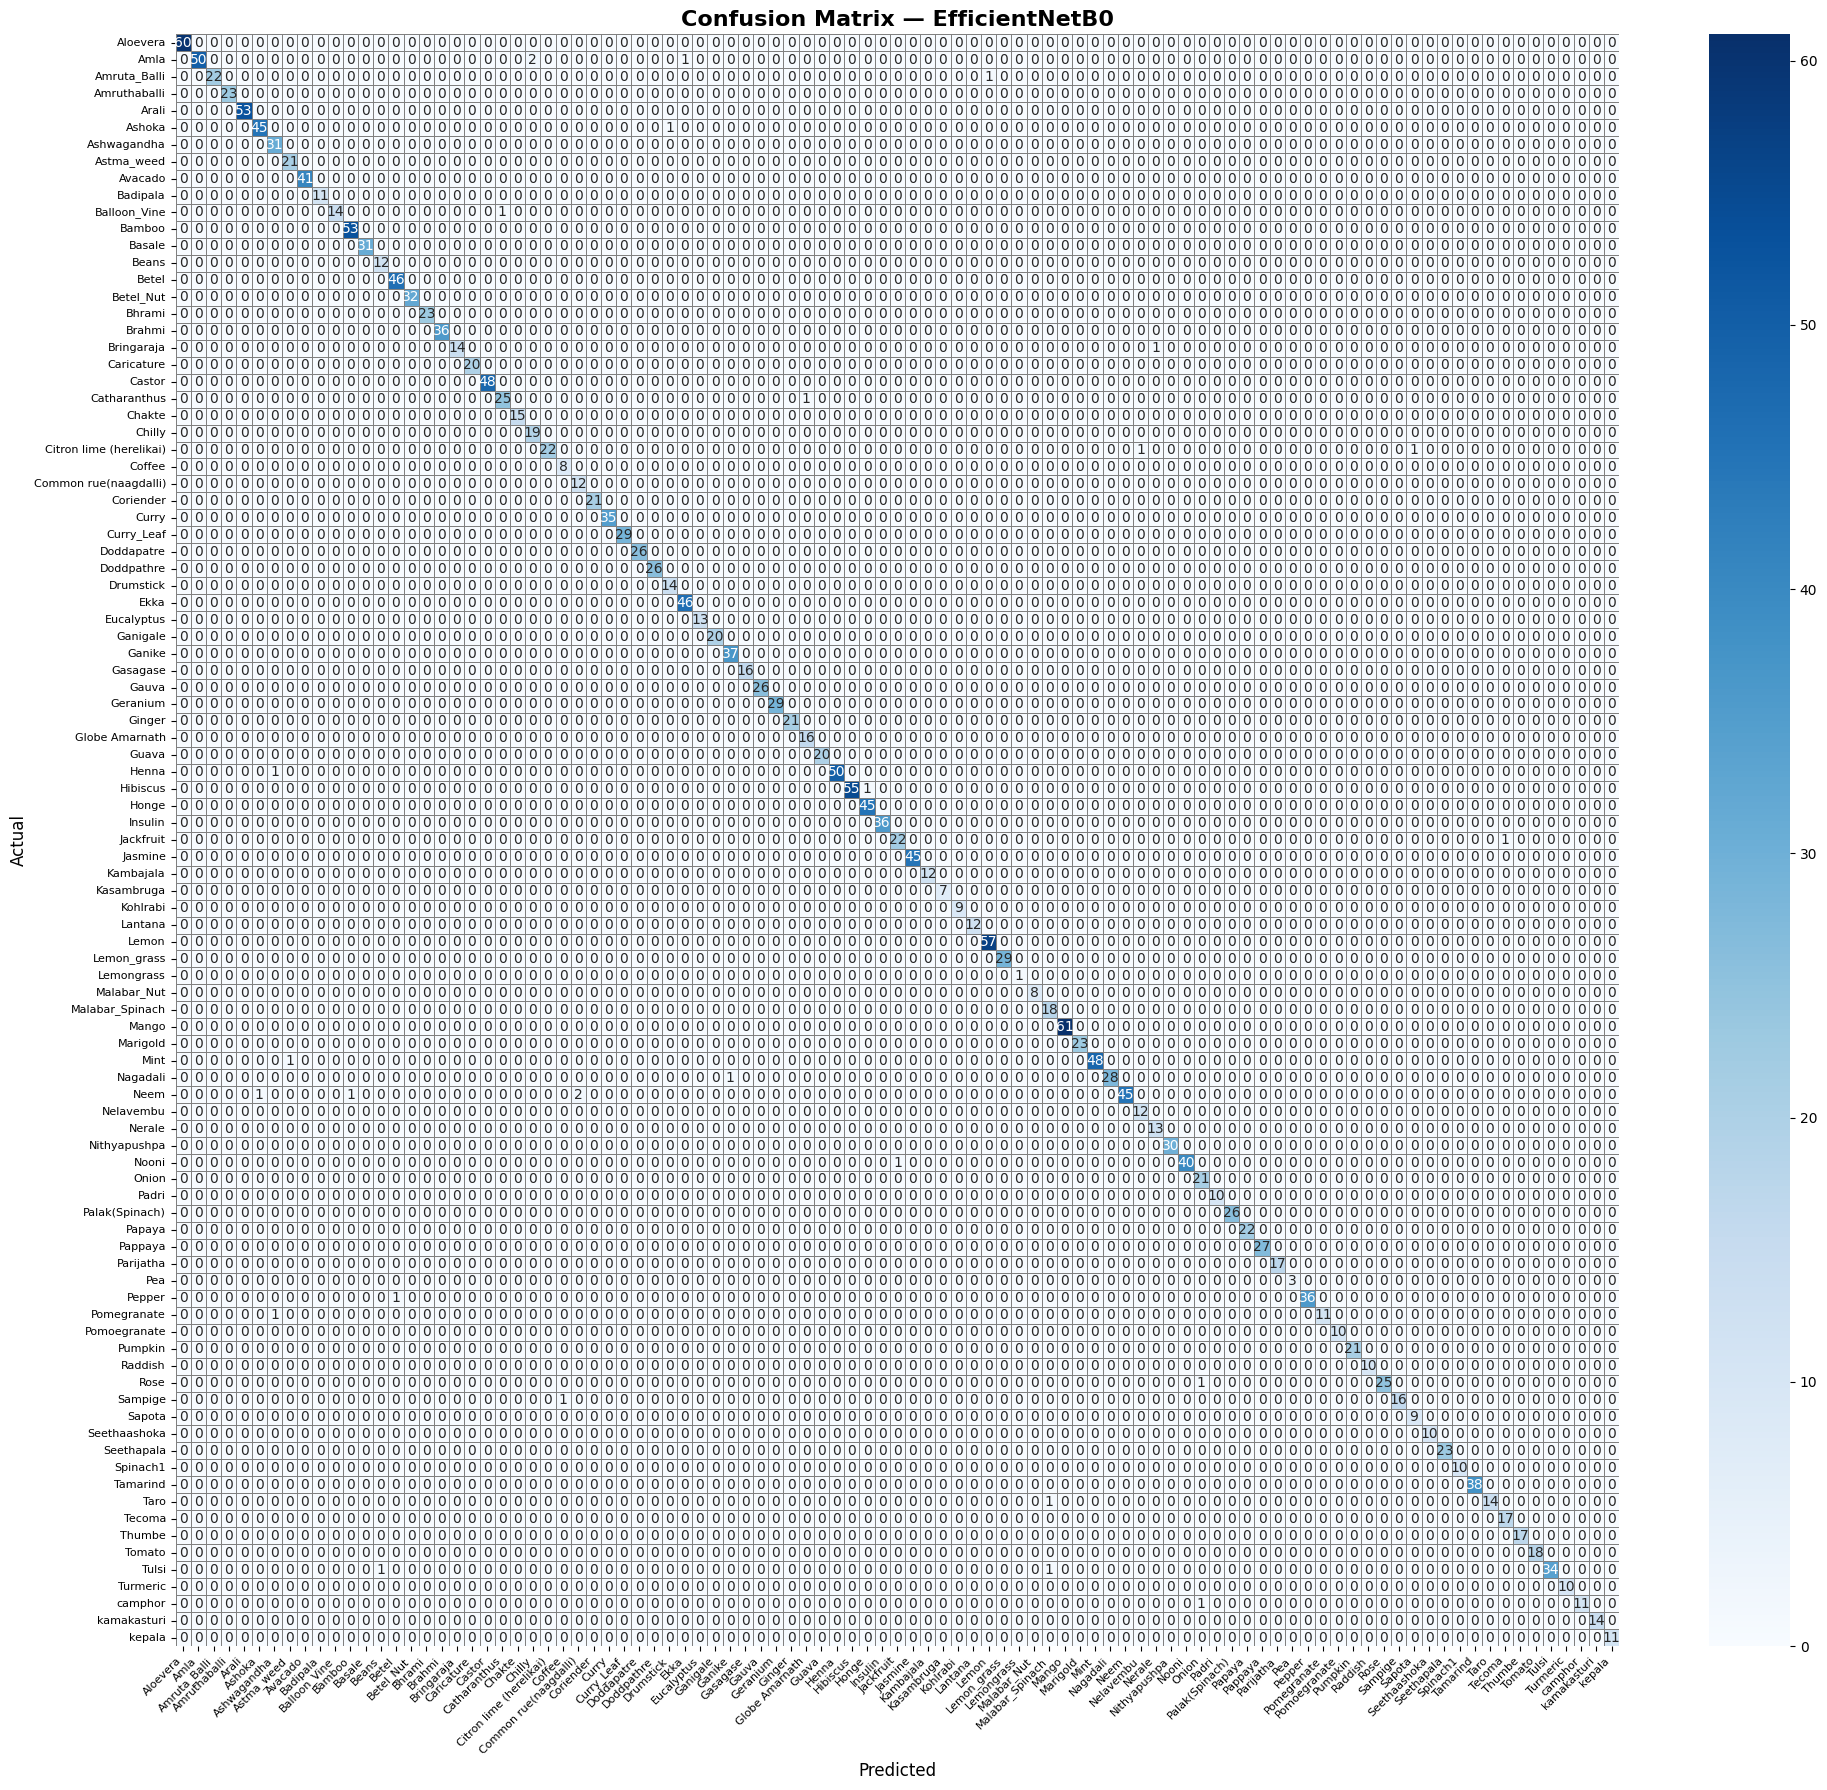

💾 Confusion matrix disimpan: D:\SMT 6\ML\BE\backend-apm-herbify\reports\evaluation\confusion_matrix_efficientnetb0.png


In [24]:
def plot_confusion_matrix(y_true, y_pred, class_names, model_name, save_path):
    """Plot dan simpan confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(20, 18))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Confusion matrix disimpan: {save_path}")

plot_confusion_matrix(results_mobilenet['labels'], results_mobilenet['preds'], class_names, "MobileNetV2", os.path.join(REPORTS_EVAL_DIR, 'confusion_matrix_mobilenetv2.png'))

# For ResNet50: only use classes present in test set
unique_labels_resnet = np.unique(results_resnet['labels'])
resnet_class_names_cm = [class_names[i] for i in unique_labels_resnet]
plot_confusion_matrix(results_resnet['labels'], results_resnet['preds'], resnet_class_names_cm, "ResNet50", os.path.join(REPORTS_EVAL_DIR, 'confusion_matrix_resnet50.png'))

plot_confusion_matrix(results_efficientnet['labels'], results_efficientnet['preds'], class_names, "EfficientNetB0", os.path.join(REPORTS_EVAL_DIR, 'confusion_matrix_efficientnetb0.png'))

### Per-Class F1-Score Comparison

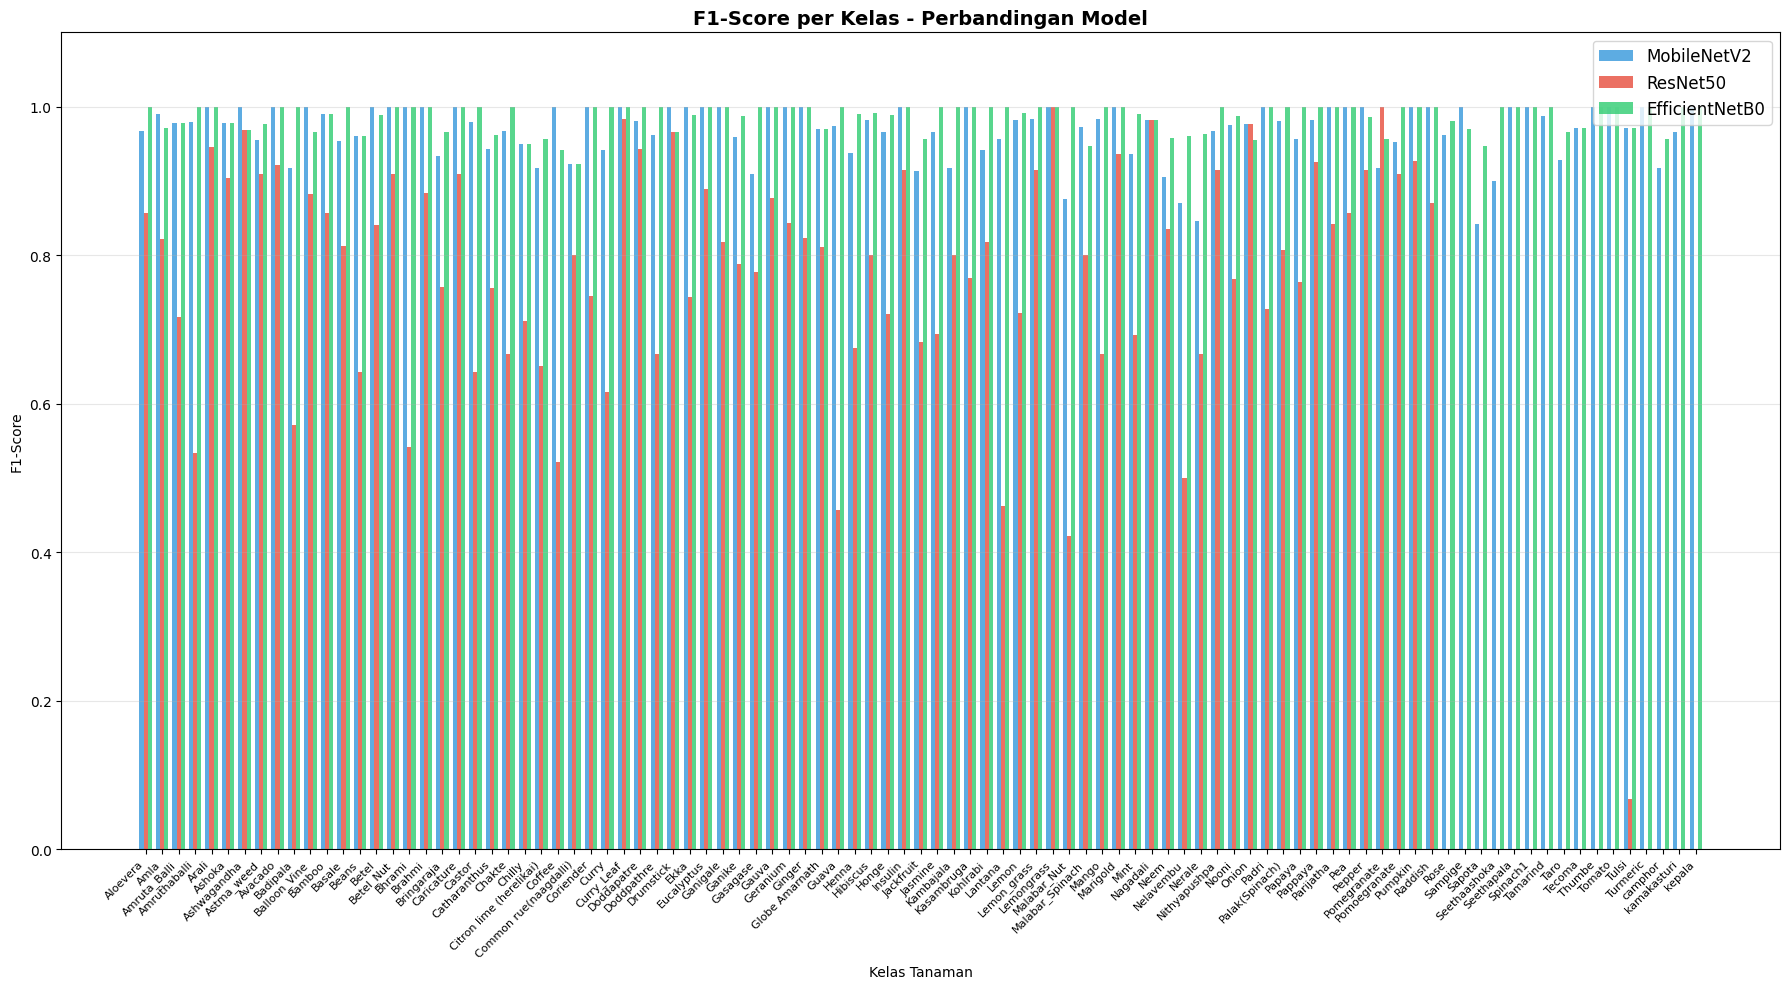

In [25]:
# Gunakan labels=range(num_classes) agar ResNet50 (98 output) hanya dihitung untuk 95 kelas
labels_range = list(range(num_classes))

report_mobilenet = classification_report(results_mobilenet['labels'], results_mobilenet['preds'], labels=labels_range, target_names=class_names, output_dict=True, zero_division=0)
report_resnet = classification_report(results_resnet['labels'], results_resnet['preds'], labels=labels_range, target_names=class_names, output_dict=True, zero_division=0)
report_efficientnet = classification_report(results_efficientnet['labels'], results_efficientnet['preds'], labels=labels_range, target_names=class_names, output_dict=True, zero_division=0)

f1_mobilenet = [report_mobilenet[cls]['f1-score'] for cls in class_names]
f1_resnet = [report_resnet[cls]['f1-score'] for cls in class_names]
f1_efficientnet = [report_efficientnet[cls]['f1-score'] for cls in class_names]

fig, ax = plt.subplots(figsize=(18, 10))
x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, f1_mobilenet, width, label='MobileNetV2', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, f1_resnet, width, label='ResNet50', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width, f1_efficientnet, width, label='EfficientNetB0', color='#2ecc71', alpha=0.8)

ax.set_title('F1-Score per Kelas - Perbandingan Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelas Tanaman')
ax.set_ylabel('F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_EVAL_DIR, 'per_class_f1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### Training History Comparison

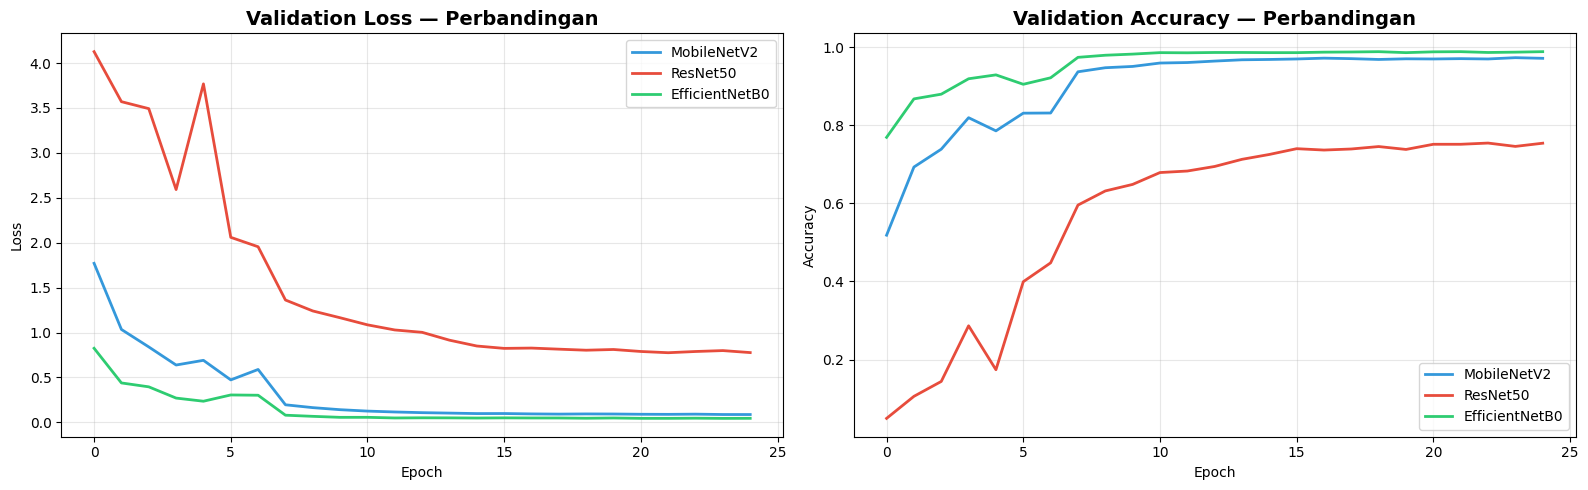

In [26]:
# Load history
with open(os.path.join(MODEL_MOBILENET_DIR, 'mobilenetv2_history.json'), 'r') as f:
    hist_mobilenet = json.load(f)
with open(os.path.join(MODEL_RESNET_DIR, 'resnet50_history.json'), 'r') as f:
    hist_resnet = json.load(f)
with open(os.path.join(MODEL_EFFICIENTNET_DIR, 'efficientnetb0_history.json'), 'r') as f:
    hist_efficientnet = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss comparison
axes[0].plot(hist_mobilenet['val_loss'], label='MobileNetV2', color='#3498db', linewidth=2)
axes[0].plot(hist_resnet['val_loss'], label='ResNet50', color='#e74c3c', linewidth=2)
axes[0].plot(hist_efficientnet['val_loss'], label='EfficientNetB0', color='#2ecc71', linewidth=2)
axes[0].set_title('Validation Loss — Perbandingan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(hist_mobilenet['val_acc'], label='MobileNetV2', color='#3498db', linewidth=2)
axes[1].plot(hist_resnet['val_acc'], label='ResNet50', color='#e74c3c', linewidth=2)
axes[1].plot(hist_efficientnet['val_acc'], label='EfficientNetB0', color='#2ecc71', linewidth=2)
axes[1].set_title('Validation Accuracy — Perbandingan', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_EVAL_DIR, 'training_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### Tabel Perbandingan Final

In [27]:
mobilenet_size = os.path.getsize(os.path.join(MODEL_MOBILENET_DIR, "mobilenetv2_best.pth")) / (1024*1024)
resnet_size = os.path.getsize(os.path.join(MODEL_RESNET_DIR, "resnet50_best.pth")) / (1024*1024)
efficientnet_size = os.path.getsize(os.path.join(MODEL_EFFICIENTNET_DIR, "efficientnetb0_best.pth")) / (1024*1024)

comparison_data = {
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 
               'Avg Inference (ms)', 'Model Size (MB)', 'Total Parameters'],
    'MobileNetV2': [
        f"{results_mobilenet['accuracy']:.4f}",
        f"{results_mobilenet['precision']:.4f}",
        f"{results_mobilenet['recall']:.4f}",
        f"{results_mobilenet['f1_score']:.4f}",
        f"{results_mobilenet['avg_inference_ms']:.2f}",
        f"{mobilenet_size:.1f}",
        f"{sum(p.numel() for p in mobilenet.parameters()):,}"
    ],
    'ResNet50': [
        f"{results_resnet['accuracy']:.4f}",
        f"{results_resnet['precision']:.4f}",
        f"{results_resnet['recall']:.4f}",
        f"{results_resnet['f1_score']:.4f}",
        f"{results_resnet['avg_inference_ms']:.2f}",
        f"{resnet_size:.1f}",
        f"{sum(p.numel() for p in resnet.parameters()):,}"
    ],
    'EfficientNetB0': [
        f"{results_efficientnet['accuracy']:.4f}",
        f"{results_efficientnet['precision']:.4f}",
        f"{results_efficientnet['recall']:.4f}",
        f"{results_efficientnet['f1_score']:.4f}",
        f"{results_efficientnet['avg_inference_ms']:.2f}",
        f"{efficientnet_size:.1f}",
        f"{sum(p.numel() for p in efficientnet.parameters()):,}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*90)
print("📊 TABEL PERBANDINGAN FINAL: MobileNetV2 vs ResNet50 vs EfficientNetB0")
print("="*90)
print(df_comparison.to_string(index=False))


📊 TABEL PERBANDINGAN FINAL: MobileNetV2 vs ResNet50 vs EfficientNetB0
            Metrik MobileNetV2   ResNet50 EfficientNetB0
          Accuracy      0.9730     0.6984         0.9884
         Precision      0.9739     0.7309         0.9891
            Recall      0.9730     0.6984         0.9884
          F1-Score      0.9729     0.7039         0.9884
Avg Inference (ms)      378.82    1581.56         307.96
   Model Size (MB)         9.2       90.7           16.0
  Total Parameters   2,345,567 23,708,834      4,129,243


### Simpan Hasil Evaluasi

In [28]:
evaluation_results = {
    'mobilenetv2': {
        'accuracy': results_mobilenet['accuracy'],
        'precision': results_mobilenet['precision'],
        'recall': results_mobilenet['recall'],
        'f1_score': results_mobilenet['f1_score'],
        'avg_inference_ms': results_mobilenet['avg_inference_ms'],
        'model_size_mb': mobilenet_size,
    },
    'resnet50': {
        'accuracy': results_resnet['accuracy'],
        'precision': results_resnet['precision'],
        'recall': results_resnet['recall'],
        'f1_score': results_resnet['f1_score'],
        'avg_inference_ms': results_resnet['avg_inference_ms'],
        'model_size_mb': resnet_size,
    },
    'efficientnetb0': {
        'accuracy': results_efficientnet['accuracy'],
        'precision': results_efficientnet['precision'],
        'recall': results_efficientnet['recall'],
        'f1_score': results_efficientnet['f1_score'],
        'avg_inference_ms': results_efficientnet['avg_inference_ms'],
        'model_size_mb': efficientnet_size,
    }
}

eval_path = os.path.join(REPORTS_EVAL_DIR, 'evaluation_results.json')
with open(eval_path, 'w') as f:
    json.dump(evaluation_results, f, indent=2)
print(f"\n💾 Hasil evaluasi disimpan: {eval_path}")


💾 Hasil evaluasi disimpan: D:\SMT 6\ML\BE\backend-apm-herbify\reports\evaluation\evaluation_results.json


### Rekomendasi Model Terbaik

In [29]:
print("\n" + "="*70)
print("🏆 REKOMENDASI MODEL UNTUK PRODUCTION")
print("="*70)

models = ['mobilenetv2', 'resnet50', 'efficientnetb0']
f1_scores = [results_mobilenet['f1_score'], results_resnet['f1_score'], results_efficientnet['f1_score']]

best_idx = np.argmax(f1_scores)
recommended = models[best_idx]

print(f"Berdasarkan F1-Score tertinggi, model yang direkomendasikan adalah: {recommended.upper()}")

print(f"   → Model '{recommended}' akan digunakan di backend API (FastAPI)")
print(f"   → File: trained_models/{recommended}_best.pth")

# Simpan rekomendasi ke file
comparison_md = f"""# Perbandingan Model: MobileNetV2 vs ResNet50 vs EfficientNetB0

## Tabel Perbandingan

{df_comparison.to_markdown(index=False)}

## Rekomendasi

**Model terbaik untuk production: {recommended.upper()}**

Model ini akan di-load oleh FastAPI backend untuk endpoint `/predict`.
"""

with open(os.path.join(REPORTS_EVAL_DIR, 'model_comparison.md'), 'w', encoding='utf-8') as f:
    f.write(comparison_md)
print(f"📄 Perbandingan disimpan: reports/model_comparison.md")


🏆 REKOMENDASI MODEL UNTUK PRODUCTION
Berdasarkan F1-Score tertinggi, model yang direkomendasikan adalah: EFFICIENTNETB0
   → Model 'efficientnetb0' akan digunakan di backend API (FastAPI)
   → File: trained_models/efficientnetb0_best.pth


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.